In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [70]:
df = pd.read_csv('cleaned_dataset.csv')



In [71]:
df.shape

(293468, 25)

#Basic Info and Shape

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293468 entries, 0 to 293467
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    293468 non-null  int64  
 1   Customer_ID       293468 non-null  int64  
 2   City              293468 non-null  object 
 3   State             293468 non-null  object 
 4   Country           293468 non-null  object 
 5   Age               293468 non-null  int64  
 6   Gender            293468 non-null  object 
 7   Income            293468 non-null  object 
 8   Customer_Segment  293468 non-null  object 
 9   Date              293468 non-null  object 
 10  Year              293468 non-null  int64  
 11  Month             293468 non-null  object 
 12  Time              293468 non-null  object 
 13  Total_Purchases   293468 non-null  int64  
 14  Amount            293468 non-null  float64
 15  Total_Amount      293468 non-null  float64
 16  Product_Category  29

In [47]:
df.describe()

,Transaction_ID,Customer_ID,Age,Year,Total_Purchases,Amount,Total_Amount,Ratings
count,2.934680e+05,293468.00000,293468.000000,293468.000000,293468.000000,293468.000000,293468.000000,293468.000000
mean,5.494777e+06,54996.88658,35.337662,2023.164860,5.362050,255.245121,1368.530075,3.164168
std,2.595679e+06,26003.92306,14.980487,0.371054,2.868189,141.424732,1129.022584,1.319651
min,1.000007e+06,10000.00000,18.000000,2023.000000,1.000000,10.000000,10.000000,1.000000
25%,3.246553e+06,32463.75000,22.000000,2023.000000,3.000000,132.900000,439.400000,2.000000
50%,5.498059e+06,54991.50000,32.000000,2023.000000,5.000000,255.530000,1042.320000,3.000000
75%,7.738007e+06,77497.00000,46.000000,2023.000000,8.000000,377.810000,2031.330000,4.000000
max,9.999995e+06,99999.00000,70.000000,2024.000000,10.000000,500.000000,4999.600000,5.000000


In [48]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
City,0
State,0
Country,0
Age,0
Gender,0
Income,0
Customer_Segment,0
Date,0


In [49]:
df.duplicated().sum()

np.int64(0)

#Outlier Detection

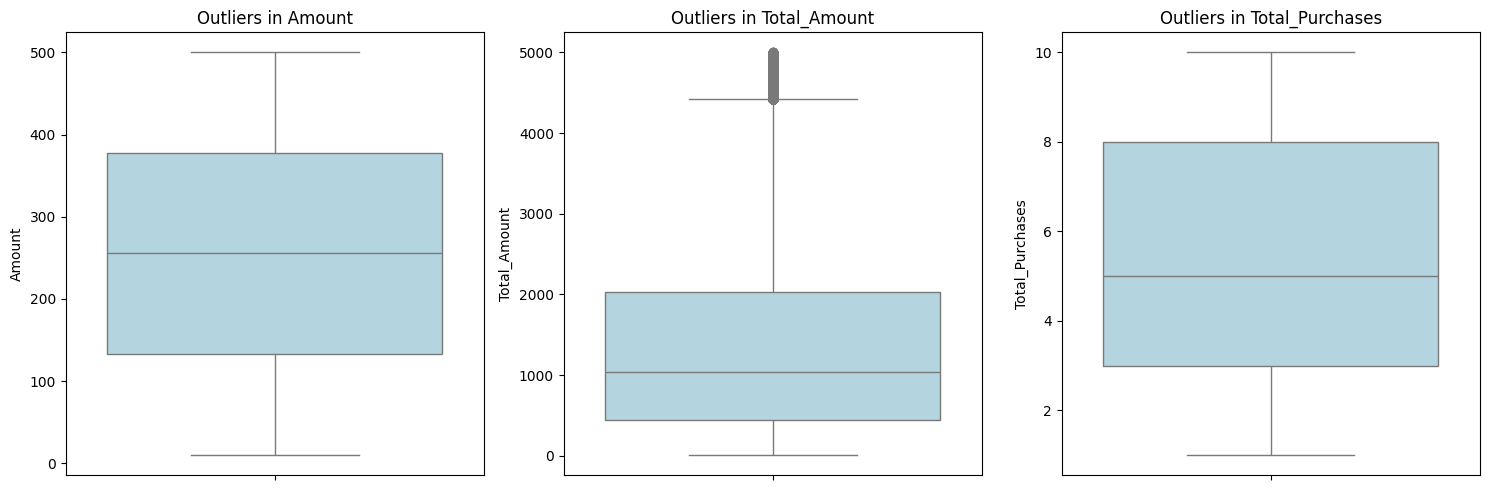

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(['Amount', 'Total_Amount', 'Total_Purchases']):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

In [51]:
# IQR Method - Count outliers
for col in ['Amount', 'Total_Amount', 'Total_Purchases']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

Amount: 0 outliers (0.00%)
Total_Amount: 3777 outliers (1.29%)
Total_Purchases: 0 outliers (0.00%)


### Observation
Only Total_Amount contains outliers (3,777 rows = 1.29% of data).
Amount and Total_Purchases have zero outliers (0.00%). Given the
dataset size (293K rows), these 3,777 high-value transactions likely
represent genuine premium purchases rather than data errors. No removal needed.

#Univariate Analysis

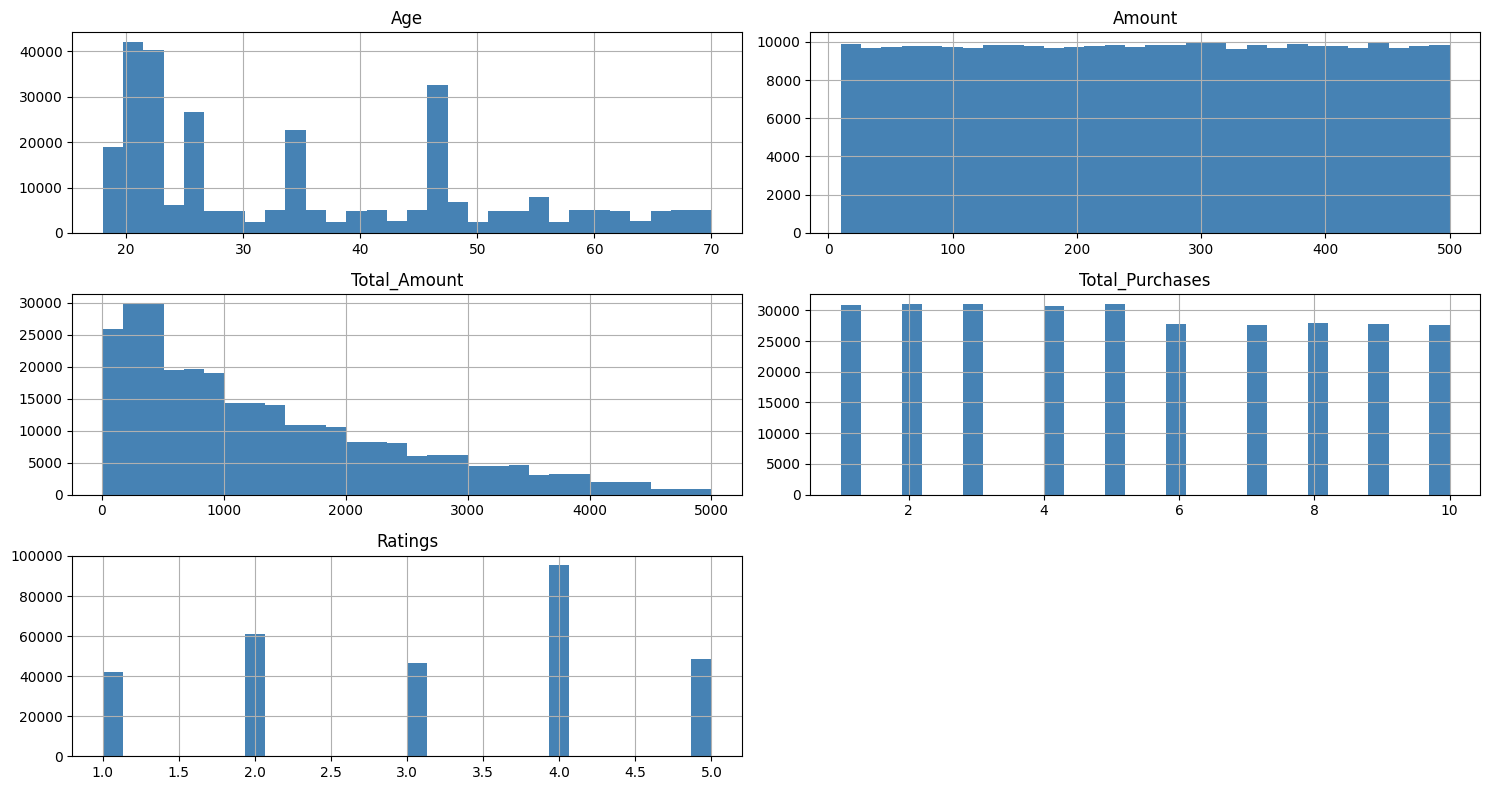

In [52]:
num_cols = ['Age', 'Amount', 'Total_Amount', 'Total_Purchases', 'Ratings']
df[num_cols].hist(bins=30, figsize=(15, 8), color='steelblue')
plt.tight_layout()
plt.show()


### Observation
Age is fairly uniformly distributed between 18-70. Amount shows a
near-uniform distribution (skewness: -0.003) suggesting no dominant
price point. Total_Amount is right-skewed (0.97) — most transactions
are low-to-mid value. Ratings spread evenly from 1-5.

In [53]:
# Skewness and Kurtosis
print("Skewness:")
print(df[num_cols].skew().round(3))
print("\nKurtosis:")
print(df[num_cols].kurtosis().round(3))

Skewness:
Age                0.666
Amount            -0.003
Total_Amount       0.972
Total_Purchases    0.072
Ratings           -0.243
dtype: float64

Kurtosis:
Age               -0.787
Amount            -1.199
Total_Amount       0.175
Total_Purchases   -1.216
Ratings           -1.166
dtype: float64


### Observation
Total_Amount is right-skewed (0.972), meaning most transactions are
low-to-mid value but a few high-value purchases pull the mean up.
Age is slightly right-skewed (0.666). Amount is nearly symmetric
(-0.003). Total_Purchases and Ratings have negative kurtosis,
indicating flat, spread-out distributions.

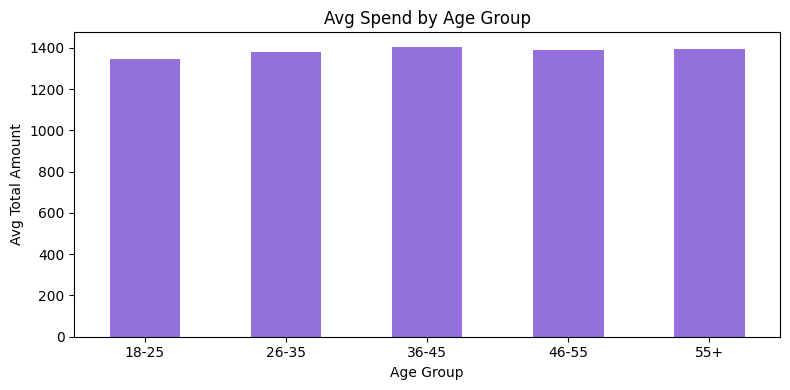

In [54]:
# Age Group Analysis
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 70],
                          labels=['18-25', '26-35', '36-45', '46-55', '55+'])

df.groupby('Age_Group', observed=True)['Total_Amount'].mean().plot(
    kind='bar', color='mediumpurple', figsize=(8, 4))
plt.title('Avg Spend by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Avg Total Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
The 36-45 age group has the highest average spend (₹1,404), while
18-25 spends the least (₹1,347). However, the difference across all
age groups is marginal (~₹58), suggesting age is not a strong
driver of purchase value in this dataset.

/tmp/ipykernel_1273/991287298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Income', y='Total_Amount', data=df,


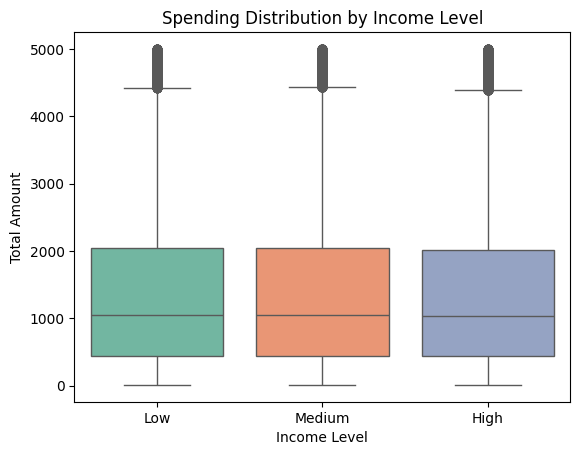

In [55]:
# Income Level vs Total Amount
income_order = ['Low', 'Medium', 'High']
sns.boxplot(x='Income', y='Total_Amount', data=df,
            order=income_order, palette='Set2')
plt.title('Spending Distribution by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Total Amount')
plt.show()

### Observation
Surprisingly, all three income groups show nearly identical average
spending (Low: ₹1,372, Medium: ₹1,370, High: ₹1,361). Income level
does not appear to significantly influence purchase amount in this
dataset, suggesting uniform pricing or product accessibility across
income segments.

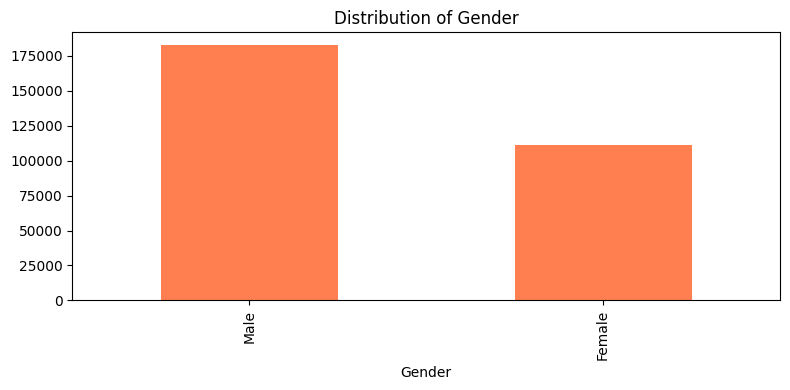

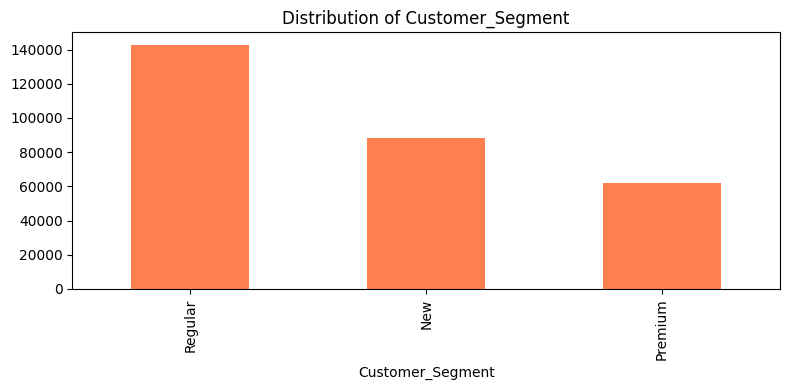

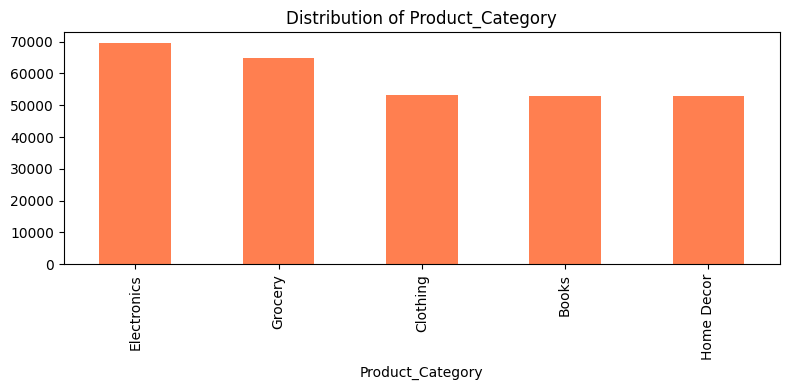

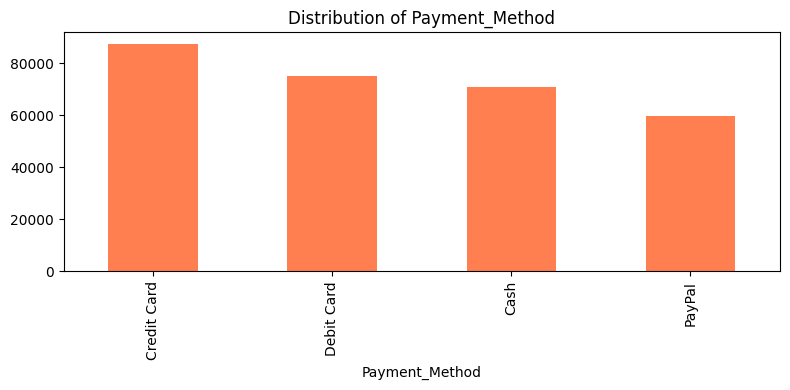

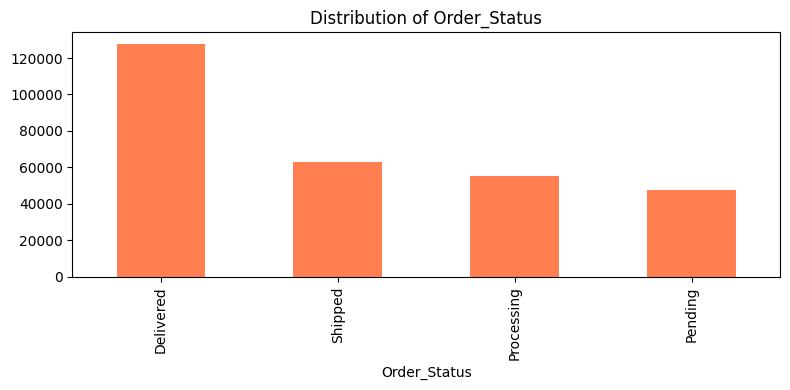

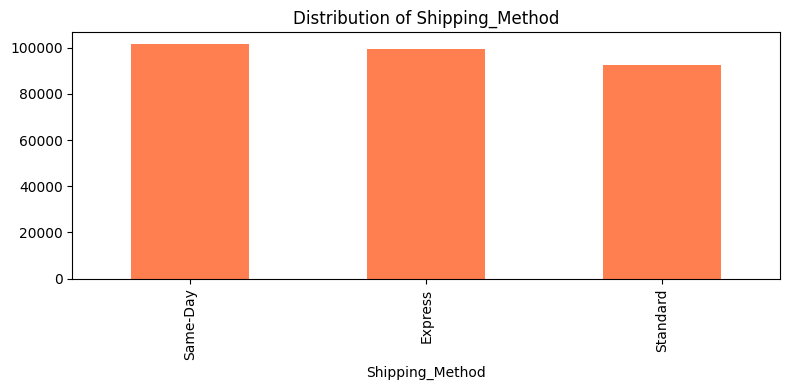

In [56]:
cat_cols = ['Gender', 'Customer_Segment', 'Product_Category',
            'Payment_Method', 'Order_Status', 'Shipping_Method']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar', color='coral')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

### Observation
Male customers significantly outnumber Female customers (62.2% vs 37.8%),
indicating a male-skewed customer base. Electronics leads all categories
by transaction count (69,443), followed closely by Grocery (64,984).
Credit Card is the most used payment method (87,444 transactions), followed
by Debit Card (75,181), Cash (70,989), and PayPal (59,854). Delivered is
the dominant order status (43.5%). Same-Day is the most used shipping method
(101,535), marginally ahead of Express (99,441) and Standard (92,492).

#Bivariate Analysis


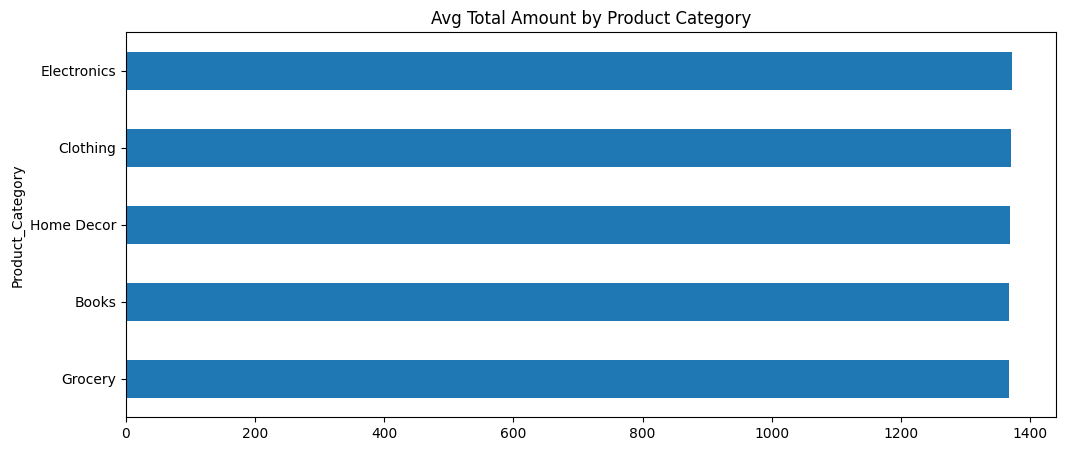

In [57]:
plt.figure(figsize=(12, 5))
df.groupby('Product_Category')['Total_Amount'].mean().sort_values().plot(kind='barh')
plt.title('Avg Total Amount by Product Category')
plt.show()

### Observation
Electronics leads with the highest average transaction value (₹1,371),
followed by Clothing (₹1,369). Grocery has the lowest avg (₹1,366).
However, the difference across all categories is only ~₹5, indicating
uniform pricing rather than category-driven revenue gaps.

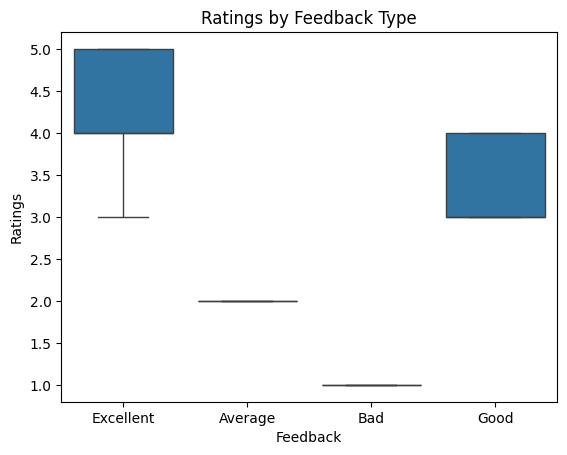

In [58]:
# Ratings vs Feedback
sns.boxplot(x='Feedback', y='Ratings', data=df)
plt.title('Ratings by Feedback Type')
plt.show()

### Observation
Each Feedback category maps directly to specific Ratings — 'Bad' = Rating 1
only, 'Average' = Rating 2 only, 'Good' = Ratings 3-4 (mean: 3.5),
'Excellent' = Ratings 3-5 (median: 4). This near-deterministic mapping
confirms that Ratings and Feedback are essentially the same information
encoded differently — using both in the same model would cause redundancy.

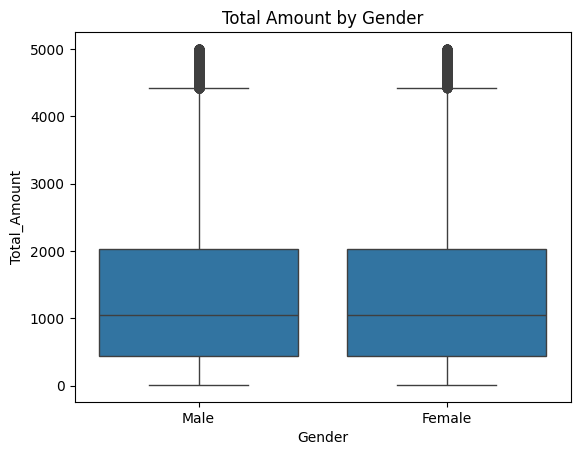

In [59]:
# Gender vs Total_Amount
sns.boxplot(x='Gender', y='Total_Amount', data=df)
plt.title('Total Amount by Gender')
plt.show()

### Observation
Male and Female customers show nearly identical spending distributions,
suggesting gender has minimal impact on purchase value in this dataset.

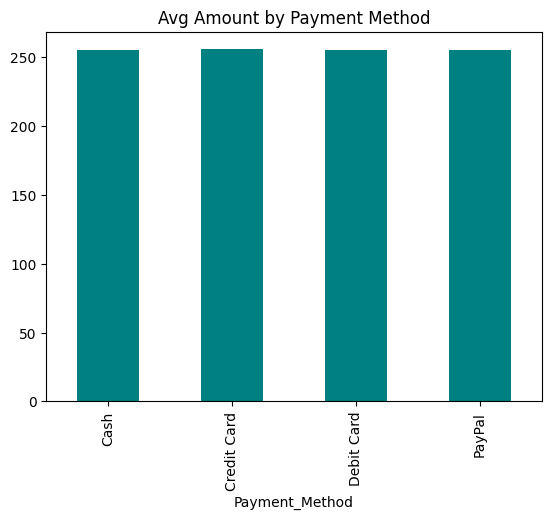

In [60]:
# Payment Method vs Amount
df.groupby('Payment_Method')['Amount'].mean().plot(kind='bar', color='teal')
plt.title('Avg Amount by Payment Method')
plt.show()

### Observation
All four payment methods show almost identical average transaction
amounts (~₹255), indicating payment preference does not influence
how much customers spend per item.

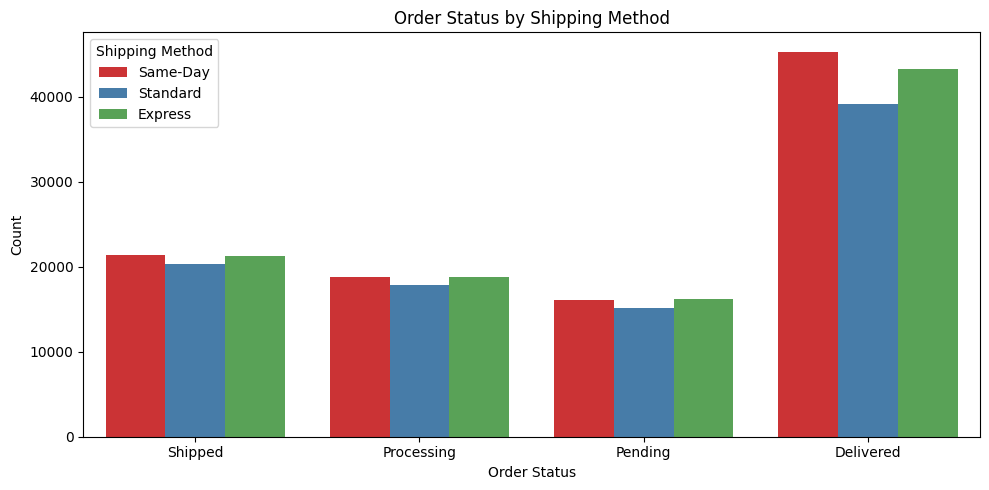

In [61]:
# Order Status vs Shipping Method
plt.figure(figsize=(10, 5))
sns.countplot(x='Order_Status', hue='Shipping_Method', data=df, palette='Set1')
plt.title('Order Status by Shipping Method')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.legend(title='Shipping Method')
plt.tight_layout()
plt.show()

### Observation
Delivered is the most common order status (43.5% of all 293K orders),
followed by Shipped (21.5%), Processing (18.9%), and Pending (16.1%).
All three shipping methods show nearly identical Delivered rates
(Same-Day: 44.6%, Express: 43.5%, Standard: 42.3%) — a difference
of only 2.3%, suggesting shipping method does not significantly
impact whether an order gets delivered.

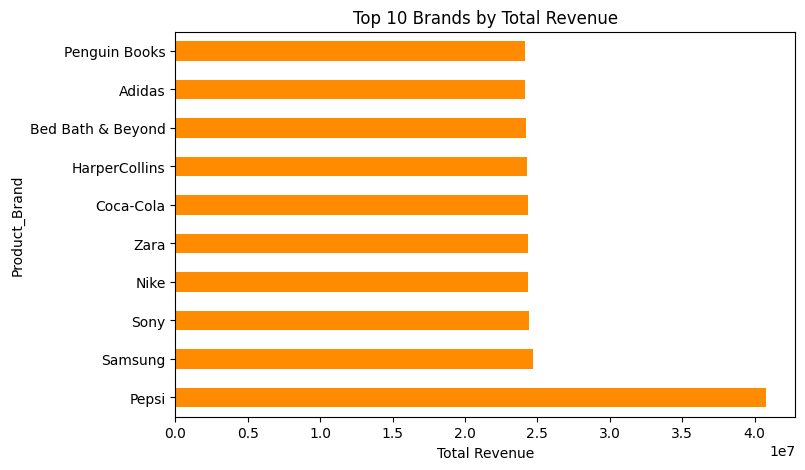

In [62]:
# Top 10 Brands by Revenue
df.groupby('Product_Brand')['Total_Amount'].sum().nlargest(10).plot(
    kind='barh', color='darkorange', figsize=(8,5))
plt.title('Top 10 Brands by Total Revenue')
plt.xlabel('Total Revenue')
plt.show()

### Observation
Pepsi dominates total revenue (₹4.07 Cr) — nearly double the next
brand — driven by high-volume Grocery purchases. Samsung (₹2.47 Cr)
and Sony (₹2.44 Cr) lead Electronics. Nike and Zara represent
Clothing/Sports. No single non-grocery brand dominates, showing
a balanced product mix.

#Correlation Heatmap


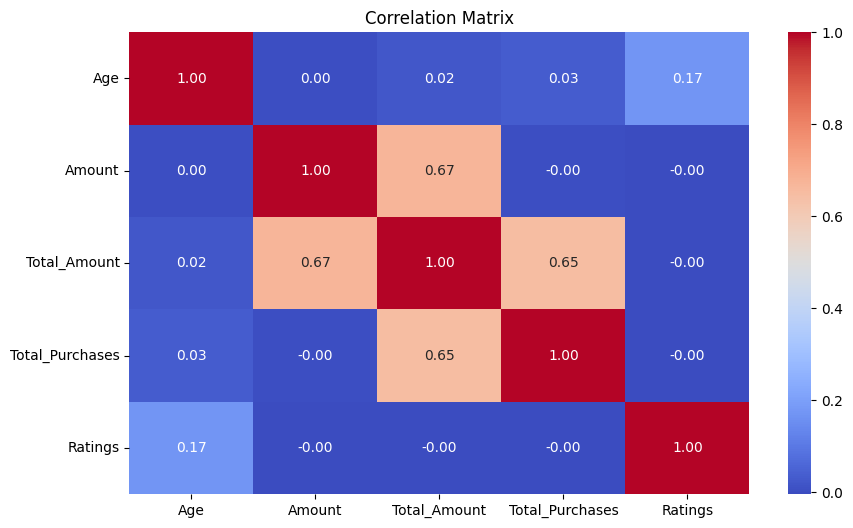

In [63]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Observation
Amount (0.67) and Total_Purchases (0.65) are both strongly correlated
with Total_Amount, as Total_Amount is derived from these two. Age shows
a mild positive correlation with Ratings (0.17), suggesting older
customers tend to give slightly higher ratings. Age has virtually no
correlation with Total_Amount (0.02), confirming age does not drive
spending behavior. All other feature pairs are near-zero, indicating
largely independent variables.

#Time-Based Analysis

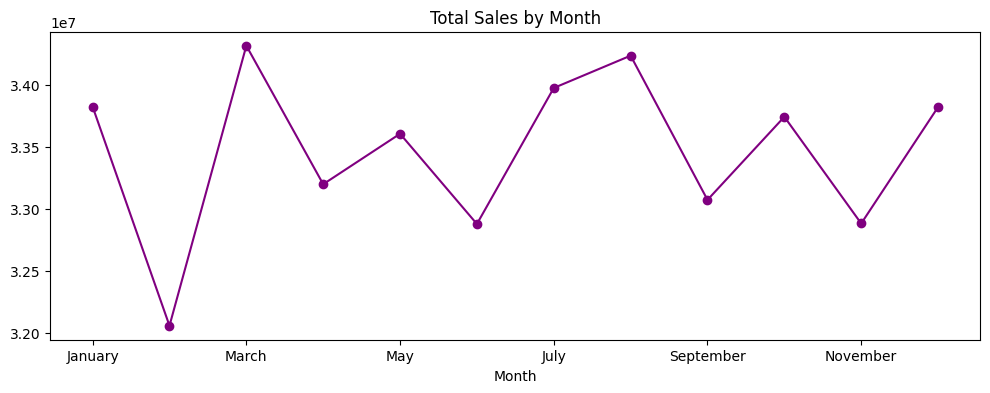

In [64]:
# Sales by Month
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df.groupby('Month')['Total_Amount'].sum().reindex(month_order)
monthly.plot(kind='line', marker='o', figsize=(12, 4), color='purple')
plt.title('Total Sales by Month')
plt.show()

### Observation
Sales are remarkably consistent across all months (₹3.2Cr–₹3.4Cr range).
March and August see the highest revenue, while February is the lowest.
The minimal variation (~6% difference between peak and trough) suggests
no strong seasonal dependency in this retail dataset.

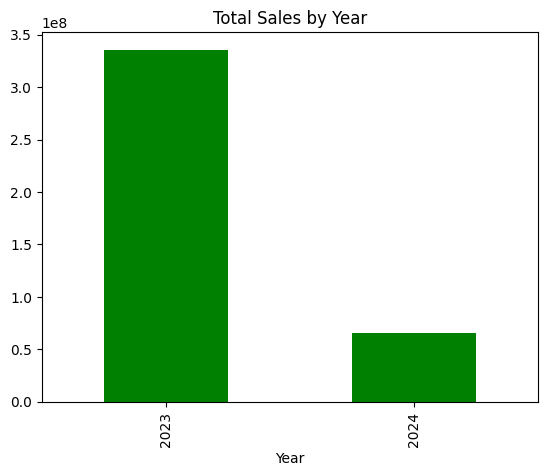

In [65]:
# Sales by Year
df.groupby('Year')['Total_Amount'].sum().plot(kind='bar', color='green')
plt.title('Total Sales by Year')
plt.show()

### Observation
2023 dominates the data with ~245K transactions vs ~48K in 2024.
2024 data is partial (not a full year), so direct year comparison
should be interpreted with caution.

#Customer Segment Analysis


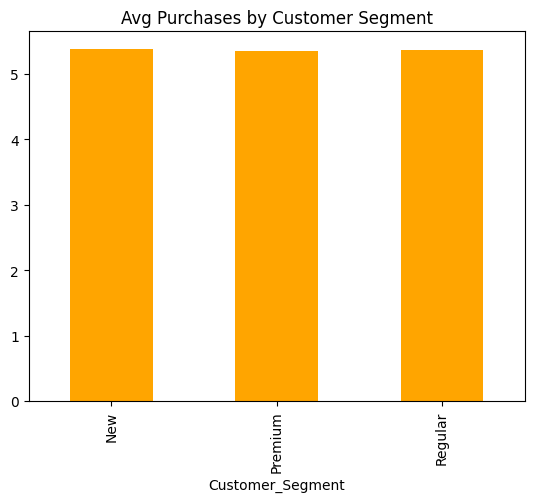

In [66]:
# Purchases per Segment
df.groupby('Customer_Segment')['Total_Purchases'].mean().plot(kind='bar', color='orange')
plt.title('Avg Purchases by Customer Segment')
plt.show()

### Observation
Average purchases per transaction are nearly identical across all segments
(New: 5.38, Regular: 5.36, Premium: 5.35), indicating that purchase
frequency does not differentiate customer segments. Segment classification
is likely based on other factors such as loyalty, total lifetime value,
or account age rather than per-transaction purchase count.

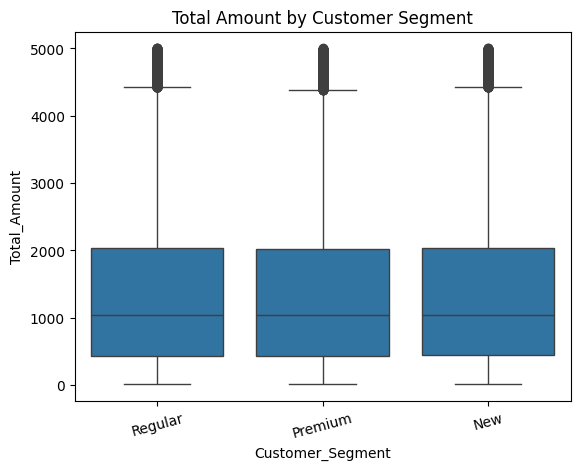

In [67]:
# Segment vs Total Amount
sns.boxplot(x='Customer_Segment', y='Total_Amount', data=df)
plt.title('Total Amount by Customer Segment')
plt.xticks(rotation=15)
plt.show()

### Observation
Regular customers form the largest segment (48.7%), followed by New (30.1%)
and Premium (21.1%). All three segments show nearly identical Total_Amount
medians — Regular: ₹1,044, New: ₹1,042, Premium: ₹1,040. Notably, Premium
customers have the lowest median spend, suggesting segment labels reflect
account tenure or loyalty tier rather than actual purchase value.

#Geographic Insights


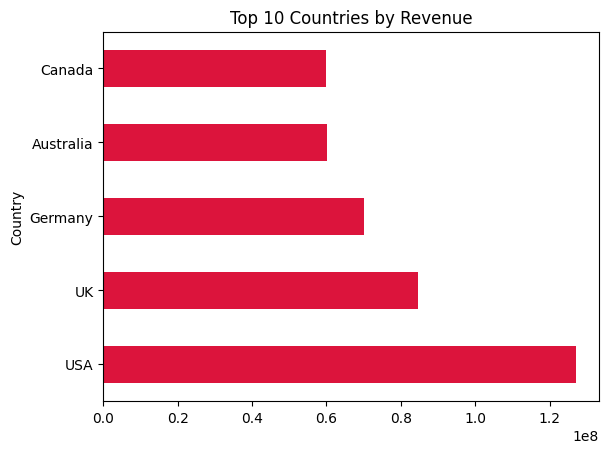

In [68]:
# Top 10 Countries by Revenue
df.groupby('Country')['Total_Amount'].sum().nlargest(10).plot(kind='barh', color='crimson')
plt.title('Top 10 Countries by Revenue')
plt.show()

### Observation
USA contributes the highest total revenue (31.6%), followed by UK (21.1%),
Germany (17.5%), Australia (15.0%), and Canada (14.9%). Revenue is fairly
distributed across all 5 countries, with no extreme concentration — even
the lowest contributor (Canada) holds ~15% share.

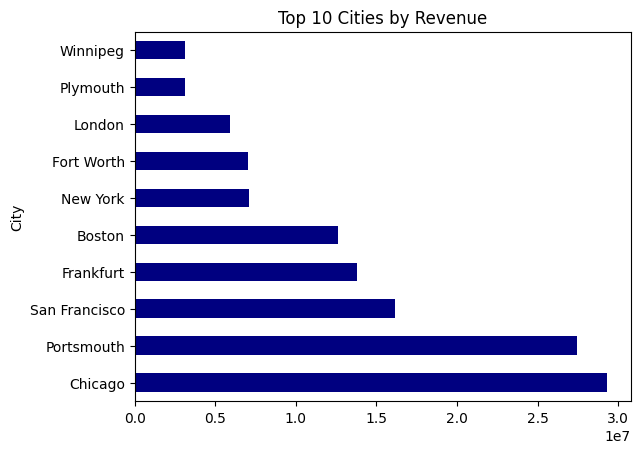

In [69]:
# Top 10 Cities
df.groupby('City')['Total_Amount'].sum().nlargest(10).plot(kind='barh', color='navy')
plt.title('Top 10 Cities by Revenue')
plt.show()

### Observation
Chicago (₹2.93 Cr) and Portsmouth (₹2.74 Cr) are the top two revenue
cities, each nearly double the third-ranked San Francisco (₹1.61 Cr).
The top 10 cities account for 31.3% of total revenue across 130 cities,
suggesting a moderately distributed customer base with a few dominant hubs.